In [56]:
import numpy as np

measurement = np.load("Diress_normal_expand.npy")

In [44]:
np.max(measurement[:, -1])


5.079466527097248

In [45]:
np.min(measurement[:, -1])

-6.058960879306612

In [46]:
np.min(measurement[:, -0])

-28.580332653143234

In [47]:
np.max(measurement[:, -0])

32.64016669513351

In [48]:
np.max(measurement[:, 1])

29.981704972518134

In [49]:
np.min(measurement[:, 1])

-31.837804273595427

In [57]:
def generate_cylinder_point_cloud(radius=30.0, height=8.0, resolution=2000):
    angles = np.random.uniform(0, 2 * np.pi, resolution)
    zs = np.random.uniform(-height / 2, height / 2, resolution)
    xs = radius * np.cos(angles)
    ys = radius * np.sin(angles)
    points = np.stack([xs, ys, zs], axis=-1)
    return points

gt_pcd = generate_cylinder_point_cloud()

In [58]:
import open3d as o3d
from scipy.spatial import cKDTree

def compute_chamfer_distance(pcd1_np, pcd2_np):
    tree1 = cKDTree(pcd1_np)
    tree2 = cKDTree(pcd2_np)
    dist1, _ = tree1.query(pcd2_np)
    dist2, _ = tree2.query(pcd1_np)
    chamfer_dist = np.mean(dist1 ** 2) + np.mean(dist2 ** 2)
    return chamfer_dist

In [59]:
cd = compute_chamfer_distance(measurement, gt_pcd)

In [60]:
print(f'Chamfer Distance between OBJ1 reconstruction and GT cylinder: {cd:.6f}')


Chamfer Distance between OBJ1 reconstruction and GT cylinder: 6.406810


In [61]:
def point_to_cylinder_distance(points, radius=30.0, height=8.0):
    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]
    r_xy = np.sqrt(x**2 + y**2)
    dr = r_xy - radius
    dz = np.abs(z) - height / 2
    dr_pos = np.maximum(dr, 0)
    dz_pos = np.maximum(dz, 0)
    distances = np.sqrt(dr_pos**2 + dz_pos**2)
    return distances



# Compute distances and RMSD
distances_meas = point_to_cylinder_distance(measurement, 30.0, 8.0)
distances_gt = point_to_cylinder_distance(gt_pcd, 30.0, 8.0)

rmsd_meas = np.sqrt(np.mean(distances_meas**2))
rmsd_gt = np.sqrt(np.mean(distances_gt**2))

print(f"RMSD (measurement to cylinder mesh): {rmsd_meas:.6f}")
print(f"RMSD (GT to cylinder mesh): {rmsd_gt:.6f}")

RMSD (measurement to cylinder mesh): 1.334744
RMSD (GT to cylinder mesh): 0.000000


In [62]:
recon_o3d = o3d.geometry.PointCloud()
recon_o3d.points = o3d.utility.Vector3dVector(measurement)
recon_o3d.paint_uniform_color([1, 0, 0])  # 红色

gt_o3d = o3d.geometry.PointCloud()
gt_o3d.points = o3d.utility.Vector3dVector(gt_pcd)
gt_o3d.paint_uniform_color([0, 1, 0])  # 绿色

o3d.visualization.draw_geometries([recon_o3d, gt_o3d])

In [8]:
z_layers_target = [0, 1, 2, 3, 4]
layer_thickness = 1.0
colors = ['red', 'orange', 'green', 'blue', 'purple']

In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

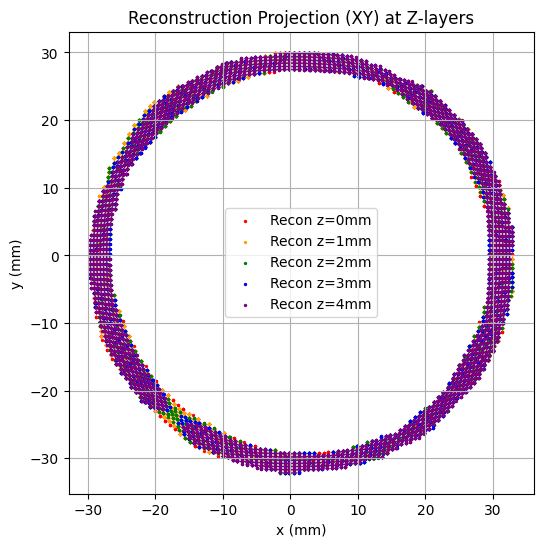

In [16]:
plt.figure(figsize=(6, 6))
for i, z_center in enumerate(z_layers_target):
    z_min = z_center - layer_thickness / 2
    z_max = z_center + layer_thickness / 2
    recon_layer = measurement[(measurement[:, 2] >= z_min) & (measurement[:, 2] < z_max)]
    recon_xy = recon_layer[:, :2]
    plt.scatter(recon_xy[:, 0], recon_xy[:, 1], color=colors[i], s=2, label=f"Recon z={z_center}mm")

plt.title("Reconstruction Projection (XY) at Z-layers")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

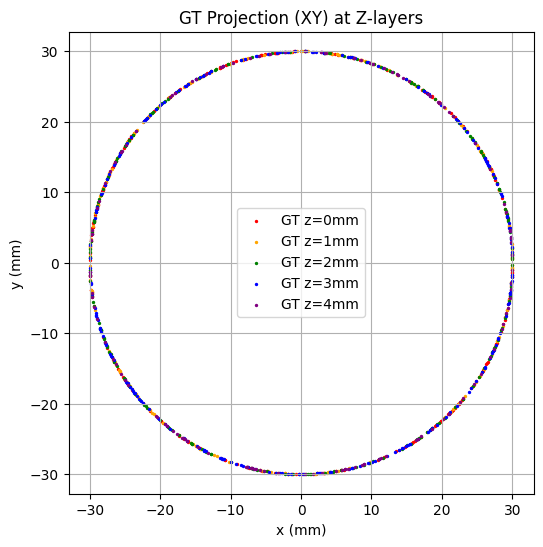

In [17]:
plt.figure(figsize=(6, 6))
for i, z_center in enumerate(z_layers_target):
    z_min = z_center - layer_thickness / 2
    z_max = z_center + layer_thickness / 2
    gt_layer = gt_pcd[(gt_pcd[:, 2] >= z_min) & (gt_pcd[:, 2] < z_max)]
    gt_xy = gt_layer[:, :2]
    plt.scatter(gt_xy[:, 0], gt_xy[:, 1], color=colors[i], s=2, label=f"GT z={z_center}mm")

plt.title("GT Projection (XY) at Z-layers")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

In [18]:
measurement = np.load("thin_point_cloud.npy")

FileNotFoundError: [Errno 2] No such file or directory: 'thin_point_cloud.npy'

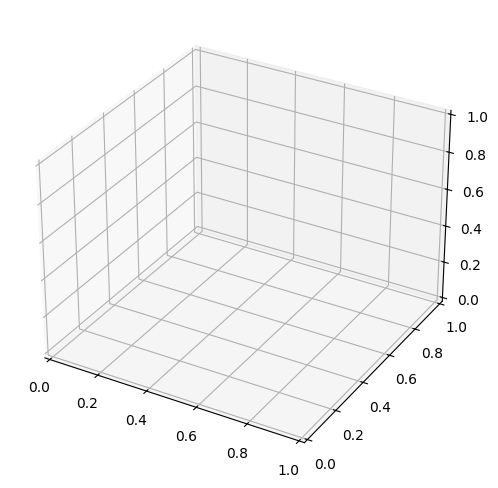

In [34]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
# Define vertical offset for visual separation
z_offset_recon = 5
z_offset_gt = 0
layer_thickness = 1.0
z_layers_target = [0, 1, 2, 3, 4]
colors = ['red', 'orange', 'green', 'blue', 'purple']

In [35]:
for i, z_center in enumerate(z_layers_target):
    z_min = z_center - layer_thickness / 2
    z_max = z_center + layer_thickness / 2
    recon_layer = measurement[(measurement[:, 2] >= z_min) & (measurement[:, 2] < z_max)]
    if len(recon_layer) > 0:
        recon_xy = recon_layer[:, :2]
        ax.scatter(recon_xy[:, 0], recon_xy[:, 1],
                   zs=z_center + z_offset_recon, zdir='z',
                   color=colors[i], alpha=0.7, s=3, label=f"Recon z={z_center}mm")

In [36]:
for i, z_center in enumerate(z_layers_target):
    z_min = z_center - layer_thickness / 2
    z_max = z_center + layer_thickness / 2
    gt_layer = gt_pcd[(gt_pcd[:, 2] >= z_min) & (gt_pcd[:, 2] < z_max)]
    if len(gt_layer) > 0:
        gt_xy = gt_layer[:, :2]
        ax.scatter(gt_xy[:, 0], gt_xy[:, 1],
                   zs=z_center + z_offset_gt, zdir='z',
                   color=colors[i], alpha=0.3, s=3, label=f"GT z={z_center}mm")

In [37]:

ax.set_title("3D Stacked Projection: Reconstruction (Top) vs GT (Bottom)")
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_zlabel("Virtual Stack Height (not actual z)")
ax.view_init(elev=30, azim=45)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [15]:
gt_pts = gt_pcd
recon_pts = measurement

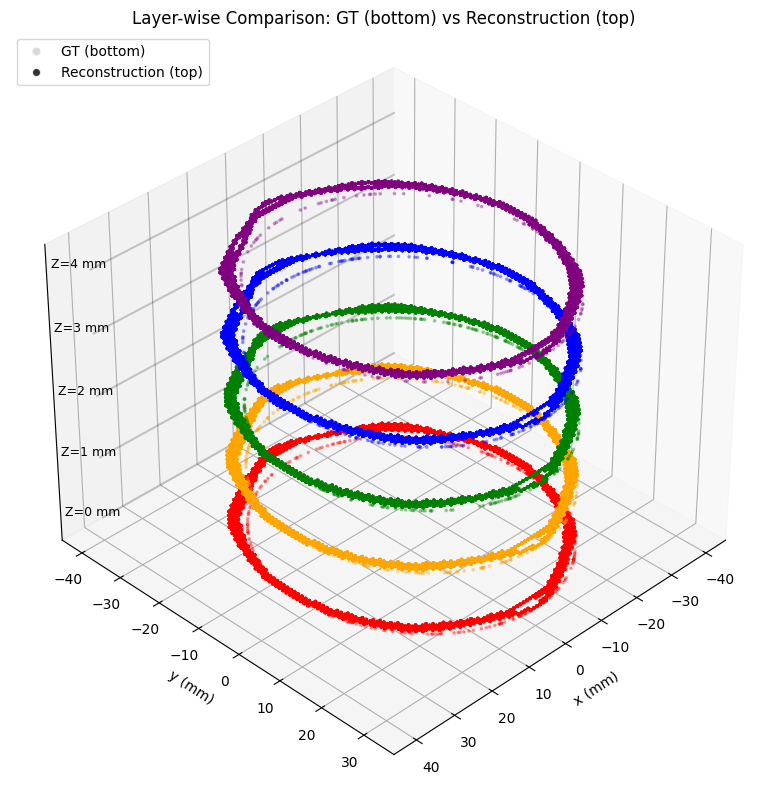

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create 3D figure
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Parameters
z_layers_target = [0, 1, 2, 3, 4]
layer_thickness = 1.0
colors = ['red', 'orange', 'green', 'blue', 'purple']
z_base = 0
z_gap = 12  # space between each layer pair
recon_offset = 2  # height difference between GT and Reconstruction within same layer

# Plot each layer pair: GT and Reconstruction
for i, z_center in enumerate(z_layers_target):
    z_min = z_center - layer_thickness / 2
    z_max = z_center + layer_thickness / 2
    color = colors[i]
    layer_z_base = z_base + i * z_gap

    # Get GT layer
    gt_layer = gt_pts[(gt_pts[:, 2] >= z_min) & (gt_pts[:, 2] < z_max)]
    if len(gt_layer) > 0:
        gt_xy = gt_layer[:, :2]
        ax.scatter(gt_xy[:, 0], gt_xy[:, 1],
                   zs=layer_z_base, zdir='z',
                   color=color, alpha=0.3, s=3,
                   label=f"GT z={z_center}mm" if i == 0 else None)

    # Get Reconstruction layer
    recon_layer = recon_pts[(recon_pts[:, 2] >= z_min) & (recon_pts[:, 2] < z_max)]
    if len(recon_layer) > 0:
        recon_xy = recon_layer[:, :2]
        ax.scatter(recon_xy[:, 0], recon_xy[:, 1],
                   zs=layer_z_base + recon_offset, zdir='z',
                   color=color, alpha=0.9, s=3,
                   label=f"Reconstruction z={z_center}mm" if i == 0 else None)

    # Add separator text
    ax.text(x=45, y=-45, z=layer_z_base + 1, s=f"Z={z_center} mm", color='black', fontsize=9)
    ax.plot([-40, 40], [-40, -40], zs=layer_z_base + 1, color='black', alpha=0.1)
    ax.plot([-40, 40], [-40, -40], zs=layer_z_base + recon_offset - 1, color='black', alpha=0.1)

# Add legend manually
custom_lines = [
    plt.Line2D([0], [0], marker='o', color='w', label='GT (bottom)', markerfacecolor='gray', markersize=6, alpha=0.3),
    plt.Line2D([0], [0], marker='o', color='w', label='Reconstruction (top)', markerfacecolor='black', markersize=6, alpha=0.8)
]
ax.legend(handles=custom_lines, loc='upper left')

# Plot settings
ax.set_title("Layer-wise Comparison: GT (bottom) vs Reconstruction (top)")
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_zlabel("")
ax.set_zticks([])
ax.view_init(elev=35, azim=45)
plt.tight_layout()
plt.show()


In [17]:
import numpy as np
import plotly.graph_objects as go

# Parameters
z_layers_target = [-4, -2, 0, 2, 4]
layer_thickness = 1.0
z_base = 0
z_gap = 15
recon_offset = 3  # vertical offset within each pair

# Define color pairs (GT, Recon) for each layer
color_pairs = [
    ("#1f77b4", "#ff7f0e"),  # blue / orange
    ("#2ca02c", "#d62728"),  # green / red
    ("#9467bd", "#8c564b"),  # purple / brown
    ("#17becf", "#e377c2"),  # cyan / pink
    ("#7f7f7f", "#bcbd22")   # gray / olive
]

# Create figure
fig = go.Figure()

for i, z_center in enumerate(z_layers_target):
    z_min = z_center - layer_thickness / 2
    z_max = z_center + layer_thickness / 2
    layer_z_base = z_base + i * z_gap
    gt_color, recon_color = color_pairs[i]

    # GT projection
    gt_layer = gt_pts[(gt_pts[:, 2] >= z_min) & (gt_pts[:, 2] < z_max)]
    if len(gt_layer) > 0:
        fig.add_trace(go.Scatter3d(
            x=gt_layer[:, 0],
            y=gt_layer[:, 1],
            z=np.ones(len(gt_layer)) * layer_z_base,
            mode='markers',
            marker=dict(size=2, color=gt_color, opacity=0.5),
            name=f"GT z={z_center*10}mm"
        ))

    # Reconstruction projection
    recon_layer = recon_pts[(recon_pts[:, 2] >= z_min) & (recon_pts[:, 2] < z_max)]
    if len(recon_layer) > 0:
        fig.add_trace(go.Scatter3d(
            x=recon_layer[:, 0],
            y=recon_layer[:, 1],
            z=np.ones(len(recon_layer)) * (layer_z_base + recon_offset),
            mode='markers',
            marker=dict(size=2, color=recon_color, opacity=0.9),
            name=f"Reconstruction z={z_center*10}mm"
        ))

# Customize layout
fig.update_layout(
    scene=dict(
        xaxis_title='x (mm)',
        yaxis_title='y (mm)',
        zaxis_title='',
        zaxis=dict(showticklabels=False),
    ),
    title="Interactive Layer-wise Projection: GT vs Reconstruction",
    legend=dict(x=0.01, y=0.99),
    margin=dict(l=0, r=0, b=0, t=30),
    height=700
)

fig.show()


In [49]:
measurement = np.load("thin_point_cloud.npy")

In [50]:
np.min(measurement[:, 0]), np.min(measurement[:, 1]), np.min(measurement[:, 2])

(np.float64(-17.170155531313117),
 np.float64(-16.90578476000003),
 np.float64(-2.8776616959999584))

In [52]:
np.max(measurement[:, 0]), np.max(measurement[:, 1]), np.max(measurement[:, 2])

(np.float64(15.82115094141415),
 np.float64(16.5057261),
 np.float64(2.8890156960000546))

In [55]:
np.max(measurement[measurement[:, -1]<-2.8][:,0]), np.max(measurement[measurement[:, 1]<-2.8][:,0])

(np.float64(15.82115094141415), np.float64(15.82115094141415))

In [60]:
np.min(measurement[measurement[:, -1]>2.8][:,0]), np.min(measurement[measurement[:, 1]>2.8][:,0])

(np.float64(-14.879092581818169), np.float64(-16.253730351515138))

In [63]:
gt_pts = gt_pcd
recon_pts = measurement
import numpy as np
import plotly.graph_objects as go

# Parameters
z_layers_target = [-2, -1, 0, 1, 2]
layer_thickness = 1.0
z_base = 0
z_gap = 15
recon_offset = 3  # vertical offset within each pair

# Define color pairs (GT, Recon) for each layer
color_pairs = [
    ("#1f77b4", "#ff7f0e"),  # blue / orange
    ("#2ca02c", "#d62728"),  # green / red
    ("#9467bd", "#8c564b"),  # purple / brown
    ("#17becf", "#e377c2"),  # cyan / pink
    ("#7f7f7f", "#bcbd22")   # gray / olive
]

# Create figure
fig = go.Figure()

for i, z_center in enumerate(z_layers_target):
    z_min = z_center - layer_thickness / 2
    z_max = z_center + layer_thickness / 2
    layer_z_base = z_base + i * z_gap
    gt_color, recon_color = color_pairs[i]

    # GT projection
    gt_layer = gt_pts[(gt_pts[:, 2] >= z_min) & (gt_pts[:, 2] < z_max)]
    if len(gt_layer) > 0:
        fig.add_trace(go.Scatter3d(
            x=gt_layer[:, 0],
            y=gt_layer[:, 1],
            z=np.ones(len(gt_layer)) * layer_z_base,
            mode='markers',
            marker=dict(size=2, color=gt_color, opacity=0.5),
            name=f"GT z={z_center*10}mm"
        ))

    # Reconstruction projection
    recon_layer = recon_pts[(recon_pts[:, 2] >= z_min) & (recon_pts[:, 2] < z_max)]
    if len(recon_layer) > 0:
        fig.add_trace(go.Scatter3d(
            x=recon_layer[:, 0],
            y=recon_layer[:, 1],
            z=np.ones(len(recon_layer)) * (layer_z_base + recon_offset),
            mode='markers',
            marker=dict(size=2, color=recon_color, opacity=0.9),
            name=f"Reconstruction z={z_center*10}mm"
        ))

# Customize layout
fig.update_layout(
    scene=dict(
        xaxis_title='x (mm)',
        yaxis_title='y (mm)',
        zaxis_title='',
        zaxis=dict(showticklabels=False),
    ),
    title="Interactive Layer-wise Projection: GT vs Reconstruction",
    legend=dict(x=0.01, y=0.99),
    margin=dict(l=0, r=0, b=0, t=30),
    height=700
)

fig.show()


In [64]:
from scipy.spatial import ConvexHull

def fit_min_enclosing_circle(points):
    """Approximate minimum enclosing circle using convex hull + max distance pair."""
    if len(points) < 2:
        return None, 0.0
    hull = ConvexHull(points)
    hull_points = points[hull.vertices]
    max_dist = 0
    center = np.array([0.0, 0.0])
    for i in range(len(hull_points)):
        for j in range(i + 1, len(hull_points)):
            p1, p2 = hull_points[i], hull_points[j]
            dist = np.linalg.norm(p1 - p2)
            if dist > max_dist:
                max_dist = dist
                center = (p1 + p2) / 2.0
    radius = max_dist / 2.0
    return center, radius

import plotly.graph_objects as go

# Parameters
z_layers_target = [0, 1, 2, 3, 4]
layer_thickness = 1.0
z_gap = 15
recon_offset = 3
color_pairs = [
    ("#1f77b4", "#ff7f0e"),
    ("#2ca02c", "#d62728"),
    ("#9467bd", "#8c564b"),
    ("#17becf", "#e377c2"),
    ("#7f7f7f", "#bcbd22")
]

fig = go.Figure()

for i, z_center in enumerate(z_layers_target):
    z_min = z_center - layer_thickness / 2
    z_max = z_center + layer_thickness / 2
    layer_z_base = i * z_gap
    gt_color, recon_color = color_pairs[i]

    # GT
    gt_layer = gt_pts[(gt_pts[:, 2] >= z_min) & (gt_pts[:, 2] < z_max)]
    if len(gt_layer) > 0:
        gt_xy = gt_layer[:, :2]
        center, radius = fit_min_enclosing_circle(gt_xy)
        fig.add_trace(go.Scatter3d(
            x=gt_xy[:, 0], y=gt_xy[:, 1], z=[layer_z_base] * len(gt_xy),
            mode='markers', marker=dict(size=2, color=gt_color, opacity=0.5),
            name=f"GT z={z_center}mm"
        ))
        # Draw GT circle
        theta = np.linspace(0, 2 * np.pi, 100)
        circle_x = center[0] + radius * np.cos(theta)
        circle_y = center[1] + radius * np.sin(theta)
        fig.add_trace(go.Scatter3d(
            x=circle_x, y=circle_y, z=[layer_z_base] * 100,
            mode='lines', line=dict(color=gt_color, width=3),
            name=f"GT Fit z={z_center}mm"
        ))

    # Recon
    recon_layer = recon_pts[(recon_pts[:, 2] >= z_min) & (recon_pts[:, 2] < z_max)]
    if len(recon_layer) > 0:
        recon_xy = recon_layer[:, :2]
        center, radius = fit_min_enclosing_circle(recon_xy)
        fig.add_trace(go.Scatter3d(
            x=recon_xy[:, 0], y=recon_xy[:, 1], z=[layer_z_base + recon_offset] * len(recon_xy),
            mode='markers', marker=dict(size=2, color=recon_color, opacity=0.8),
            name=f"Recon z={z_center}mm"
        ))
        # Draw recon circle
        theta = np.linspace(0, 2 * np.pi, 100)
        circle_x = center[0] + radius * np.cos(theta)
        circle_y = center[1] + radius * np.sin(theta)
        fig.add_trace(go.Scatter3d(
            x=circle_x, y=circle_y, z=[layer_z_base + recon_offset] * 100,
            mode='lines', line=dict(color=recon_color, width=3),
            name=f"Recon Fit z={z_center}mm"
        ))

# Layout
fig.update_layout(
    scene=dict(
        xaxis_title='x (mm)',
        yaxis_title='y (mm)',
        zaxis=dict(title='', showticklabels=False),
    ),
    title="Interactive GT vs Reconstruction with Fitted Minimum Enclosing Circles",
    margin=dict(l=0, r=0, b=0, t=30),
    height=750,
    showlegend=True
)

fig.show()


In [65]:
import numpy as np
import plotly.graph_objects as go
from scipy.spatial import ConvexHull

def extract_ring(points, epsilon=1.0):
    """Extract middle ring of points based on distance to center."""
    if len(points) < 3:
        return points
    center = np.mean(points, axis=0)
    dists = np.linalg.norm(points - center, axis=1)
    r_mean = np.mean(dists)
    mask = (dists >= r_mean - epsilon) & (dists <= r_mean + epsilon)
    return points[mask]

# 层参数
z_layers_target = [0, 1, 2, 3, 4]
layer_thickness = 1.0
z_gap = 15
recon_offset = 3
epsilon = 1.0  # 控制“中间一圈”的厚度
color_pairs = [
    ("#1f77b4", "#ff7f0e"),
    ("#2ca02c", "#d62728"),
    ("#9467bd", "#8c564b"),
    ("#17becf", "#e377c2"),
    ("#7f7f7f", "#bcbd22")
]

fig = go.Figure()

for i, z_center in enumerate(z_layers_target):
    z_min = z_center - layer_thickness / 2
    z_max = z_center + layer_thickness / 2
    layer_z_base = i * z_gap
    gt_color, recon_color = color_pairs[i]

    # ---- GT ----
    gt_layer = gt_pts[(gt_pts[:, 2] >= z_min) & (gt_pts[:, 2] < z_max)]
    if len(gt_layer) > 0:
        gt_xy = gt_layer[:, :2]
        ring_pts = extract_ring(gt_xy, epsilon)
        fig.add_trace(go.Scatter3d(
            x=ring_pts[:, 0], y=ring_pts[:, 1], z=[layer_z_base] * len(ring_pts),
            mode='markers', marker=dict(size=2, color=gt_color, opacity=0.5),
            name=f"GT Ring z={z_center}mm"
        ))

    # ---- Reconstruction ----
    recon_layer = recon_pts[(recon_pts[:, 2] >= z_min) & (recon_pts[:, 2] < z_max)]
    if len(recon_layer) > 0:
        recon_xy = recon_layer[:, :2]
        ring_pts = extract_ring(recon_xy, epsilon)
        fig.add_trace(go.Scatter3d(
            x=ring_pts[:, 0], y=ring_pts[:, 1], z=[layer_z_base + recon_offset] * len(ring_pts),
            mode='markers', marker=dict(size=2, color=recon_color, opacity=0.9),
            name=f"Recon Ring z={z_center}mm"
        ))

# 布局设置
fig.update_layout(
    scene=dict(
        xaxis_title='x (mm)',
        yaxis_title='y (mm)',
        zaxis=dict(title='', showticklabels=False),
    ),
    title="Interactive Ring-wise Projection: GT vs Reconstruction",
    height=800,
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()
